In [45]:
!hostname

cn132.wexac.weizmann.ac.il


In [46]:
import os
import sys
import numpy as np
import cv2 
import pandas as pd
import logging

RUN_EFFECT_SIZE_PAIR_WISE_COMPARISON = False
RUN_EFFECT_SIZE_AGGREGATED_COMPARISON = False

MODEL_PATH = f"/home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen"
# ---WORKING ENV SETUP---
NOVA_HOME = '/home/projects/hornsteinlab/Collaboration/NOVA' 
# home/projects/hornsteinlab/giliwo/NOVA
#'/home/projects/hornsteinlab/Collaboration/NOVA' 
NOVA_DATA_HOME = '/home/projects/hornsteinlab/Collaboration/NOVA'
NOVA_LOCAL = "/home/projects/hornsteinlab/Collaboration/Guy_Lior"
OUTPUT_DIR = os.path.join(NOVA_LOCAL, "fuNOVA_Pilot2", "Effect_size")
CONFIG_PATHS = [
    # TDP
    "./NOVA/manuscript/effects_config/AATNOVAEffectConfigC9_NTvsKD",
    "./NOVA/manuscript/effects_config/AATNOVAEffectConfigCTL_NTvsKD",
    "./NOVA/manuscript/effects_config/AATNOVAEffectConfigKD_CTLvsC9",
    "./NOVA/manuscript/effects_config/AATNOVAEffectConfigNT_CTLvsC9_onlyKD",
    ]
KD_LIST = ["PPP2R1A","HMGCS1","PIK3C3","NDUFAB1","MAPKAP1","NDUFS2","RALA","TLK1","NRIP1","TARDBP","RANBP17","CYLD"]

SCALE_MIN = 0.0
SCALE_MAX = 0.25

os.environ['NOVA_HOME'] = NOVA_HOME
os.environ['NOVA_LOCAL'] = NOVA_LOCAL
sys.path.insert(1, os.getenv("NOVA_HOME"))
print(f"NOVA_HOME: {os.getenv('NOVA_HOME')}")
print(f"NOVA_LOCAL: {os.getenv('NOVA_LOCAL')}")

from src.analysis.analyzer_effects import AnalyzerEffects
from src.analysis.analyzer_effects_dist_ratio import AnalyzerEffectsDistRatio
from src.common.utils import load_config_file, get_class
from src.embeddings.embeddings_utils import load_embeddings
# _compute_effect_size_baseline_distance(self, group_baseline:np.ndarray[float],
#                                               group_pert:np.ndarray[float])->np.ndarray[float]:


%load_ext autoreload
%autoreload 2

NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA
NOVA_LOCAL: /home/projects/hornsteinlab/Collaboration/Guy_Lior
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:


def _calculate_all_effects_pilot(embeddings_df: pd.DataFrame, baseline_perturb_dict, 
                               embeddings_dim:int, anz_dist_ratio:AnalyzerEffectsDistRatio) -> pd.DataFrame:
        

        results = []
        for baseline in baseline_perturb_dict:
            baseline_cell_line, baseline_cond = baseline.split('_')
            baseline_df = embeddings_df[
                                (embeddings_df.cell_line == baseline_cell_line) &
                                (embeddings_df.condition == baseline_cond)]
            for pert in baseline_perturb_dict[baseline]:
                pert_cell_line, pert_cond = pert.split('_')
                pert_df = embeddings_df[
                                (embeddings_df.cell_line == pert_cell_line) &
                                (embeddings_df.condition == pert_cond)]
                
                # Group each DataFrame by marker and batch separately
                baseline_groups = baseline_df.groupby(['marker', 'batch'])
                pert_groups = pert_df.groupby(['marker', 'batch'])
                # Iterate over marker-batch keys that appear in both baseline and perturbed
                common_batch_marker_keys = set(baseline_groups.groups.keys()) & set(pert_groups.groups.keys())
                common_batch_marker_keys = sorted(common_batch_marker_keys)
                for key in common_batch_marker_keys:
                    marker, batch = key
                    
                    batch_marker_baseline_df = baseline_groups.get_group(key)
                    batch_marker_pert_df = pert_groups.get_group(key)

                    baseline_embeddings = batch_marker_baseline_df.iloc[:, :embeddings_dim].values[np.newaxis, ...]
                    perturb_embeddings = batch_marker_pert_df.iloc[:, :embeddings_dim].values[np.newaxis, ...]
                    res = anz_dist_ratio._compute_effect_size_baseline_distance(baseline_embeddings, perturb_embeddings)

                    # res = self._calculate_effect_per_batch(batch_marker_baseline_df, 
                                                            # batch_marker_pert_df, embeddings_dim, 
                                                            # min_required, n_boot)
                    if res:
                        tmp_res = {'effect_size': res, 'marker': marker, 'baseline': baseline, 'pert': pert, 'batch': batch, "n_baseline": baseline_embeddings.shape[1], "n_pert": perturb_embeddings.shape[1]}
                        results.append(tmp_res)
        return pd.DataFrame(results)




In [48]:
def _calculate_aggregated_effect(embeddings_df: pd.DataFrame, 
                                 baseline_cell_lines:list[str], 
                                 baseline_conditions:list[str], 
                                 pert_cell_lines:list[str], 
                                 pert_conditions:list[str], 
                               embeddings_dim:int, anz_dist_ratio:AnalyzerEffectsDistRatio) -> pd.DataFrame:
        

                results = []
                base_line_str = "_".join(baseline_cell_lines) + ":" + "_".join(baseline_conditions)
                pert_line_str = "_".join(pert_cell_lines) + ":" + "_".join(pert_conditions)

                baseline_df = embeddings_df[
                                (embeddings_df.cell_line.isin(baseline_cell_lines)) &
                                (embeddings_df.condition.isin(baseline_conditions))]

                pert_df = embeddings_df[
                                (embeddings_df.cell_line.isin(pert_cell_lines)) &
                                (embeddings_df.condition.isin(pert_conditions))]
                
                # Group each DataFrame by marker and batch separately
                baseline_groups = baseline_df.groupby(['marker', 'batch'])
                pert_groups = pert_df.groupby(['marker', 'batch'])
                # Iterate over marker-batch keys that appear in both baseline and perturbed
                common_batch_marker_keys = set(baseline_groups.groups.keys()) & set(pert_groups.groups.keys())
                common_batch_marker_keys = sorted(common_batch_marker_keys)
                for key in common_batch_marker_keys:
                    marker, batch = key
                    
                    batch_marker_baseline_df = baseline_groups.get_group(key)
                    batch_marker_pert_df = pert_groups.get_group(key)

                    baseline_embeddings = batch_marker_baseline_df.iloc[:, :embeddings_dim].values[np.newaxis, ...]
                    perturb_embeddings = batch_marker_pert_df.iloc[:, :embeddings_dim].values[np.newaxis, ...]
                    res = anz_dist_ratio._compute_effect_size_baseline_distance(baseline_embeddings, perturb_embeddings)

                    # res = self._calculate_effect_per_batch(batch_marker_baseline_df, 
                                                            # batch_marker_pert_df, embeddings_dim, 
                                                            # min_required, n_boot)
                    if res:
                        tmp_res = {'effect_size': res, 'marker': marker, 'baseline': base_line_str, 'pert': pert_line_str, 'batch': batch, "n_baseline": baseline_embeddings.shape[1], "n_pert": perturb_embeddings.shape[1]}
                        results.append(tmp_res)
                    
                return pd.DataFrame(results)

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
def parse_results(kd, total_reults, suffix = "", order = True):
    os.makedirs(os.path.join(OUTPUT_DIR, kd), exist_ok=True)
    total_reults.to_csv(os.path.join(OUTPUT_DIR, kd, f"{kd}_effect_sizes{suffix}.csv"), index=False)
    df = total_reults.copy()
    df["effect_size"] = df["effect_size"].str[0]
    out_df = (
        df
        .groupby(["marker", "baseline", "pert"], as_index=False)
        .apply(
            lambda g: pd.Series({
                "weighted_effect_size": np.average(
                    g["effect_size"],
                    weights=g["n_baseline"] + g["n_pert"]
                ),
                "baseline_counts": dict(zip(g["batch"], g["n_baseline"])),
                "pert_counts": dict(zip(g["batch"], g["n_pert"])),
            }),
            include_groups=False
        )
    )
    out_df.to_csv(os.path.join(OUTPUT_DIR, kd, f"{kd}_weighted_effect_sizes{suffix}.csv"), index=False)

    out_df["comparison"] = out_df["baseline"] + " VS " + out_df["pert"]
    heat_df = out_df.pivot(
        index="marker",
        columns="comparison",
        values="weighted_effect_size"
    )

    if order:
        # order comparision labels
        x_order = ["CTL_NT-1873 VS C9_NT-1873", f"CTL_{kd} VS C9_{kd}", f"CTL_NT-1873 VS CTL_{kd}", f"C9_NT-1873 VS C9_{kd}"]  
        # Reindex the DataFrame
        heat_df = heat_df.reindex(columns= x_order)

    plt.figure(figsize=(14, 8))
    sns.heatmap(
        heat_df,
        cmap="RdBu_r",
        center=0,
        cbar_kws={"label": "Effect Size"},
        vmin=SCALE_MIN,
        vmax=SCALE_MAX,
    )

    plt.title("Effect Sizes Across Conditions")
    plt.ylabel("Marker")
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, kd, f"{kd}_effect_size_hetamap{suffix}.png"))


In [50]:

if RUN_EFFECT_SIZE_PAIR_WISE_COMPARISON:
    for kd in KD_LIST:
        print("X" * 50)
        print("analyzing: ", kd)
        results_dfs = []
        for config_path in CONFIG_PATHS:
            config_path = config_path.replace("KD", kd)
            print("*" * 50)
            print("analyzing: ", os.path.basename(config_path))
            # -----------load effect config-----------
            run_config = load_config_file(config_path, 'effect', savefolder=NOVA_LOCAL)
            run_config.OUTPUTS_FOLDER = MODEL_PATH
            # Marker filtration
            # MARKER_NAME = "TDP-43"
            # run_config.MARKERS = [MARKER_NAME]
            run_config.MARKERS_TO_EXCLUDE = ["p62", "POM121", "pS6", "pAMPK", "Brightfield"]

            #-----------init analyzer classes---------
            anz_ef = AnalyzerEffects(run_config, MODEL_PATH)
            anz_dist_ratio = AnalyzerEffectsDistRatio(run_config, MODEL_PATH)

            #-----------load embeddings----------------
            embeddings, labels, paths = load_embeddings(MODEL_PATH, run_config)
            emb_df = anz_ef._prepare_embeddings_df(embeddings, labels, paths)

            #-----------calculate effects-------------
            baseline_perturb_dict = {run_config.BASELINE: [run_config.PERTURBATION]}
            print("baseline_perturb_dict", baseline_perturb_dict)
            emb_dim = embeddings.shape[1]
            results = _calculate_all_effects_pilot(emb_df, baseline_perturb_dict, emb_dim, anz_dist_ratio)
            results_dfs.append(results)
            print("*" * 50)
        print("X" * 50)
        total_reults = pd.concat(results_dfs)
        parse_results(kd, total_reults)


In [51]:
BASE_CONFIG = "./NOVA/manuscript/effects_config/AATNOVAEffectConfig"


# baseline_cell_lines, baseline_conditions, pert_cell_lines, pert_conditions
compare_dict = {
    "C9+CTL_NT_vs_KD": (["C9", "CTL"], ["NT-1873"], ["C9", "CTL"], ["KD"]),
    "CTL_vs_C9_NT+KD": (["CTL"], ["NT-1873", "KD"], ["C9"], ["NT-1873", "KD"])
}

if RUN_EFFECT_SIZE_AGGREGATED_COMPARISON:
    for kd in KD_LIST:
        print("X" * 50)
        print("analyzing: ", kd)
        results_dfs = []

        compare_dict = {
        "C9+CTL_NT_vs_KD": (["C9", "CTL"], ["NT-1873"], ["C9", "CTL"], [kd]),
        "CTL_vs_C9_NT+KD": (["CTL"], ["NT-1873", kd], ["C9"], ["NT-1873", kd])
    }
        for key, value in compare_dict.items():
            baseline_cell_lines, baseline_conditions, pert_cell_lines, pert_conditions = value
            print("*" * 50)
            print("analyzing: ", key)
            # -----------load effect config-----------
            run_config = load_config_file(BASE_CONFIG, 'effect', savefolder=NOVA_LOCAL)
            run_config.OUTPUTS_FOLDER = MODEL_PATH
            # Marker filtration
            # MARKER_NAME = "TDP-43"
            # run_config.MARKERS = [MARKER_NAME]
            run_config.MARKERS_TO_EXCLUDE = ["p62", "POM121", "pS6", "pAMPK", "Brightfield"]
            run_config.CELL_LINES = baseline_cell_lines + pert_cell_lines
            run_config.CONDITIONS = baseline_conditions + pert_conditions

            #-----------init analyzer classes---------
            anz_ef = AnalyzerEffects(run_config, MODEL_PATH)
            anz_dist_ratio = AnalyzerEffectsDistRatio(run_config, MODEL_PATH)

            #-----------load embeddings----------------
            embeddings, labels, paths = load_embeddings(MODEL_PATH, run_config)
            emb_df = anz_ef._prepare_embeddings_df(embeddings, labels, paths)

            #-----------calculate effects-------------
            print("BASE LINE: ", "cell lines - ", baseline_cell_lines, "conditions - ", baseline_conditions)
            print("PERT: ", "cell lines - ", pert_cell_lines, "conditions - ", pert_conditions)
            emb_dim = embeddings.shape[1]
            results = _calculate_aggregated_effect(emb_df, baseline_cell_lines, baseline_conditions, pert_cell_lines, pert_conditions, emb_dim, anz_dist_ratio)
            results_dfs.append(results)
            print("*" * 50)
        print("X" * 50)
        total_reults = pd.concat(results_dfs)
        parse_results(kd, total_reults, suffix="_aggregated", order=False)


In [52]:
# all KDs heatmaps
BASELINE_PERT = [("CTL_NT-1873", "CTL_KD"), ("C9_NT-1873", "C9_KD")]
MARKERS = ["DAPI", "ATF4", "FK-2", "SMI32", "pDRP1", "TOMM20", "pCaMKIIa", "pTDP-43", "TDP-43", "ATF6", "G3BP1", "PAR", "UNC13A", "Calreticulin", "CathepsinD"]

TEMP_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "All_KDs_VS_NT-1873")
os.makedirs(TEMP_OUTPUT_DIR, exist_ok=True)


print("OUTPUT_DIR:", OUTPUT_DIR)
all_df = []
for marker in MARKERS:
    marker_df = []
    print("*" * 20)
    print(f"Processing marker: {marker}")
    #itirate on subdirs
    for kd_name in os.listdir(OUTPUT_DIR):
        if kd_name not in KD_LIST:  
            continue
        print(f"Processing KD: {kd_name}")
        kd_df = []
        for baseline, pert in BASELINE_PERT:
            df = pd.read_csv(os.path.join(OUTPUT_DIR, kd_name, f"{kd_name}_weighted_effect_sizes.csv"))
            df = df[df["marker"] == marker]
            pert = pert.replace("KD", kd_name)

            print(f"Generating heatmap for -{baseline} VS {pert}")
            df = df[(df["baseline"] == baseline) & (df["pert"] == pert)]
            df["KD"] = kd_name

            assert baseline.split('_')[0] == pert.split('_')[0], "Baseline and perturbed must be from the same cell_line"
            cell_line = baseline.split('_')[0]
            df["cell_line"] = cell_line
            if len(df) == 0:
                print(f"No data, skipping...")
                continue
            kd_df.append(df)

        # add KD values
        kd_df = pd.concat(kd_df)
        marker_df.append(kd_df)

        # # Calculate delta effect size
        # delta_df = pd.DataFrame({
        #     "marker": [marker],
        #     "KD": [kd_name]
        # })
        # CTL_values = kd_df[kd_df["cell_line"] == "CTL"]["weighted_effect_size"].clip(lower=0).values
        # C9_values = kd_df[kd_df["cell_line"] == "C9"]["weighted_effect_size"].clip(lower=0).values
        # if len(CTL_values) == 0 or len(C9_values) == 0:
        #     print(f"Insufficient data for delta effect size calculation, skipping...")
        #     continue
        # delta_df["delta_effect_size"] = C9_values - CTL_values
        # all_df.append(delta_df)

    marker_df = pd.concat(marker_df)
    plot_df = marker_df.copy()
    # safety
    plot_df["weighted_effect_size"] = plot_df["weighted_effect_size"].clip(lower=0)
    # keep only what we need
    plot_df = plot_df[["marker", "KD", "cell_line", "weighted_effect_size"]]

    all_df.append(plot_df)

    # # rearrange for heatmap
    # marker_df_pivot = marker_df.pivot(index="KD", columns=["cell_line"], values="weighted_effect_size")

    # # order cell lines
    # x_order = ["CTL", "C9"]  
    # marker_df_pivot = marker_df_pivot.reindex(columns= x_order)

    # # plot heatmap
    # plt.figure(figsize=(10, 6))
    # sns.heatmap(
    #     marker_df_pivot,
    #     cmap="RdBu_r",
    #     center=0,
    #     cbar_kws={"label": "Effect Size"},
    #     vmin=SCALE_MIN,
    #     vmax=SCALE_MAX,
    # )   
    # plt.title(f"Effect Sizes for {marker} Across KDs (VS NT-1873)")
    # plt.ylabel("KD Gene")
    # plt.xlabel("")
    # plt.tight_layout()
    # plt.savefig(os.path.join(TEMP_OUTPUT_DIR, f"Marker_{marker}_weighted_effect_size_heatmap.png"))

all_df = pd.concat(all_df)

# all_df_pivot = all_df.pivot(index="marker", columns=["KD"], values="delta_effect_size")
# print("all_df_pivot:", all_df_pivot)
# # plot heatmap
# plt.figure(figsize=(10, 6))
# sns.heatmap(
#     all_df_pivot,
#     cmap="RdBu_r",
#     center=0,
#     cbar_kws={"label": "DeltaEffect Size"},
#     vmin=-SCALE_MAX,
#     vmax=SCALE_MAX,
# )   
# plt.title(f"Delta Effect Sizes for Across KDs and Markers (VS NT-1873)")
# plt.ylabel("Marker")
# plt.xlabel("Gene KD")
# plt.tight_layout()
# plt.savefig(os.path.join(TEMP_OUTPUT_DIR, f"All_KDs_All_Markers_Delta_effect_size_heatmap.png"))

markers = all_df["marker"].unique()


OUTPUT_DIR: /home/projects/hornsteinlab/Collaboration/Guy_Lior/fuNOVA_Pilot2/Effect_size
********************
Processing marker: DAPI
Processing KD: MAPKAP1
Generating heatmap for -CTL_NT-1873 VS CTL_MAPKAP1
Generating heatmap for -C9_NT-1873 VS C9_MAPKAP1
Processing KD: NRIP1
Generating heatmap for -CTL_NT-1873 VS CTL_NRIP1
Generating heatmap for -C9_NT-1873 VS C9_NRIP1
Processing KD: PPP2R1A
Generating heatmap for -CTL_NT-1873 VS CTL_PPP2R1A
Generating heatmap for -C9_NT-1873 VS C9_PPP2R1A
Processing KD: TLK1
Generating heatmap for -CTL_NT-1873 VS CTL_TLK1
Generating heatmap for -C9_NT-1873 VS C9_TLK1
Processing KD: RANBP17
Generating heatmap for -CTL_NT-1873 VS CTL_RANBP17
Generating heatmap for -C9_NT-1873 VS C9_RANBP17
Processing KD: PIK3C3
Generating heatmap for -CTL_NT-1873 VS CTL_PIK3C3
Generating heatmap for -C9_NT-1873 VS C9_PIK3C3
Processing KD: HMGCS1
Generating heatmap for -CTL_NT-1873 VS CTL_HMGCS1
Generating heatmap for -C9_NT-1873 VS C9_HMGCS1
Processing KD: NDUFS2
Gene

In [53]:
print(all_df.head())

   marker       KD cell_line  weighted_effect_size
19   DAPI  MAPKAP1       CTL              0.045717
16   DAPI  MAPKAP1        C9              0.011567
19   DAPI    NRIP1       CTL              0.059949
16   DAPI    NRIP1        C9              0.032681
18   DAPI  PPP2R1A       CTL              0.079282


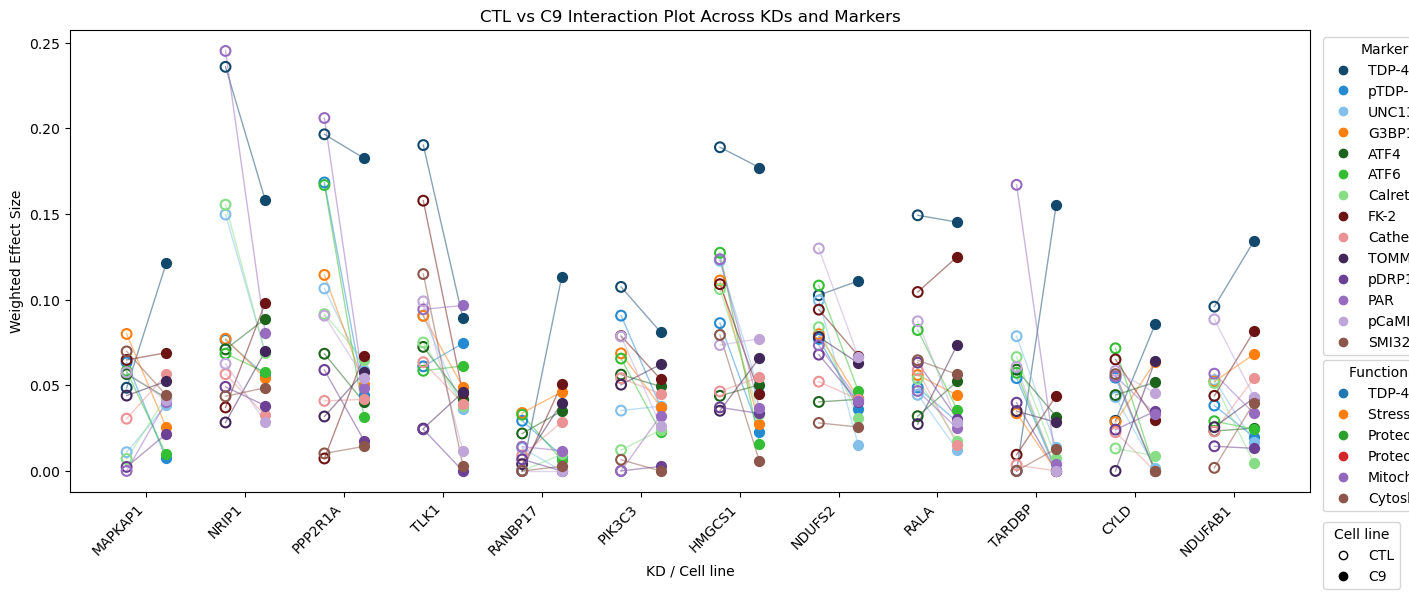

In [71]:
import colorsys
kds = all_df["KD"].unique()
markers = all_df["marker"].unique()


########## define x ticks positions #############
x_pos = {}
xticks = []
xtick_labels = []
x = 0
for kd in kds:
    x_pos[(kd, "CTL")] = x
    x_ctl = x
    x += 1

    x_pos[(kd, "C9")] = x
    x_c9 = x
    x += 1

    xticks.append((x_ctl + x_c9) / 2)
    xtick_labels.append(kd)

    x += 0.5  # spacing between KDs

######### assign colors per marker #############
base_colors = sns.color_palette("Spectral", len(markers))
marker_colors = {}
for marker, (r, g, b) in zip(markers, base_colors):
    h, l, s = colorsys.rgb_to_hls(r, g, b)

    # reduce lightness only if too bright
    if l > 0.7:
        l *= 0.5

    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    marker_colors[marker] = (r2, g2, b2)

########### assign color per functional group ############
functional_marker_groups = {
    "TDP-43 pathology": ["TDP-43", "pTDP-43", "UNC13A"],
    "Stress Granules": ["G3BP1"],
    "Proteostasis_ER": ["ATF4", "ATF6", "Calreticulin"],
    "Proteostasis_Deg": ["FK-2", "CathepsinD"],
    "Mitochondria": ["TOMM20", "pDRP1", "PAR", "pCaMKIIa"],
    "Cytoskeleton": ["SMI32"],
}

# one base color per functional group
group_names = list(functional_marker_groups.keys())
group_base_colors = dict(
    zip(group_names, sns.color_palette("tab10", len(group_names)))
)
marker_colors_functional = {}
# shades per marker within functional group
for group, markers_in_group in functional_marker_groups.items():
    base_r, base_g, base_b = group_base_colors[group]

    # convert base color to HLS
    h, l, s = colorsys.rgb_to_hls(base_r, base_g, base_b)

    # reduce lightness only if too bright
    if l > 0.7:
        l *= 0.6
        r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
        group_base_colors[group] = (r2, g2, b2)

    n = len(markers_in_group)

    # create lightness range for shades
    # darker → lighter within same group
    lightness_values = (
        [l] if n == 1 else
        # np.linspace(max(0.35, l - 0.2), min(0.75, l + 0.15), n)
        np.linspace(
            max(0.25, l - 0.35),
            min(0.75, l + 0.3),
            n
        )
    )

    for marker, l_i in zip(markers_in_group, lightness_values):
        r2, g2, b2 = colorsys.hls_to_rgb(h, l_i, s)
        marker_colors_functional[marker] = (r2, g2, b2)

def adjust_alpha(color, alpha):
    return (*color, alpha)

def plot_basic_interaction_plot(marker_colors_dict):
    fig, ax = plt.subplots(figsize=(16, 6))
    markers = marker_colors_dict.keys()
    for marker in markers:
        df_m = all_df[all_df["marker"] == marker]
        base_color = marker_colors_dict[marker]

        for kd in kds:
            sub = df_m[df_m["KD"] == kd]
            if set(sub["cell_line"]) != {"CTL", "C9"}:
                continue

            ctl = sub[sub["cell_line"] == "CTL"]["weighted_effect_size"].values[0]
            c9  = sub[sub["cell_line"] == "C9"]["weighted_effect_size"].values[0]

            x_ctl = x_pos[(kd, "CTL")]
            x_c9  = x_pos[(kd, "C9")]

            # connecting line
            ax.plot(
                [x_ctl, x_c9],
                [ctl, c9],
                color=base_color,
                alpha=0.5,
                linewidth=1
            )

            # CTL – hollow
            ax.scatter(
                x_ctl, ctl,
                facecolors="none",
                edgecolors=base_color,
                s=50,
                linewidth=1.5,
                zorder=3
            )

            # C9 – filled
            ax.scatter(
                x_c9, c9,
                facecolors=base_color,
                edgecolors=base_color,
                s=50,
                zorder=3
            )
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, rotation=45, ha="right")

    ax.set_ylabel("Weighted Effect Size")
    ax.set_xlabel("KD / Cell line")
    ax.set_title("CTL vs C9 Interaction Plot Across KDs and Markers")


    return fig, ax


# ######### plot basic interaction plot #############
# fig, ax = plot_basic_interaction_plot(marker_colors)
# # legend (marker-based)
# marker_handles = [
#     plt.Line2D(
#         [0], [0],
#         marker='o',
#         linestyle='',
#         markerfacecolor=color,
#         markeredgecolor=color,
#         label=marker
#     )
#     for marker, color in marker_colors.items()
# ]

# leg1 = ax.legend(
#     handles=marker_handles,
#     title="Marker",
#     bbox_to_anchor=(1.005, 1),
#     loc="upper left"
# )
# ax.add_artist(leg1)

style_handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='none',
        markeredgecolor='black',
        label='CTL'
    ),
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='black',
        markeredgecolor='black',
        label='C9'
    )
    ]

# ax.legend(
#     handles=style_handles,
#     title="Cell line",
#     bbox_to_anchor=(1.005, 0.2),
#     loc="upper left"
#     )
# plt.savefig(os.path.join(TEMP_OUTPUT_DIR, "All_KDs_All_Markers_interaction_plot.png"), bbox_inches='tight', dpi=300,pad_inches=0.8)

# ######### plot interaction plot with functional groups #############
fig, ax = plot_basic_interaction_plot(marker_colors_functional)
marker_handles_functional = []
for group, markers_in_group in functional_marker_groups.items():
    for marker in markers_in_group:
        color = marker_colors_functional[marker]
        marker_handles_functional.append(
            plt.Line2D(
                [0], [0],
                marker='o',
                linestyle='',
                markerfacecolor=color,
                markeredgecolor=color,
                label=f"{marker}"
            )
        )
groups_handels = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=group_base_colors[group],
        markeredgecolor=group_base_colors[group],
        label=f"{group}"
    )
    for group in functional_marker_groups.keys()
]
leg1 = ax.legend(
    handles=marker_handles_functional,
    title="Markers",
    bbox_to_anchor=(1.005, 1),
    loc="upper left"
)
ax.add_artist(leg1)

leg_2 = ax.legend(
    handles=groups_handels,
    title="Functional groups",
    bbox_to_anchor=(1.005, 0.3),
    loc="upper left"
)
ax.add_artist(leg_2)
ax.legend(
    handles=style_handles,
    title="Cell line",
    bbox_to_anchor=(1.005, -0.05),
    loc="upper left"
    )
plt.savefig(os.path.join(TEMP_OUTPUT_DIR, "All_KDs_All_Markers_functional_groups_interaction_plot.png"), bbox_inches='tight', dpi=300,pad_inches=1.1)

In [ ]:
# all KDs heatmaps
BASELINE_PERT = [("C9_CTL:NT-1873", "C9_CTL:KD")]
MARKERS = ["DAPI", "ATF4", "FK-2", "SMI32", "pDRP1", "TOMM20", "pCaMKIIa", "pTDP-43", "TDP-43", "ATF6", "G3BP1", "PAR", "UNC13A", "Calreticulin", "CathepsinD"]

TEMP_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "All_KDs_VS_NT-1873")
os.makedirs(TEMP_OUTPUT_DIR, exist_ok=True)


print("OUTPUT_DIR:", OUTPUT_DIR)
all_df = []
for marker in MARKERS:
    marker_df = []
    print("*" * 20)
    print(f"Processing marker: {marker}")
    #itirate on subdirs
    for kd_name in os.listdir(OUTPUT_DIR):
        if kd_name not in KD_LIST:  
            continue
        print(f"Processing KD: {kd_name}")
        kd_df = []
        for baseline, pert in BASELINE_PERT:
            df = pd.read_csv(os.path.join(OUTPUT_DIR, kd_name, f"{kd_name}_weighted_effect_sizes_aggregated.csv"))
            df = df[df["marker"] == marker]
            pert = pert.replace("KD", kd_name)

            print(f"Generating heatmap for -{baseline} VS {pert}")
            df = df[(df["baseline"] == baseline) & (df["pert"] == pert)]
            df["KD"] = kd_name

            assert baseline.split(':')[0] == pert.split(':')[0], "Baseline and perturbed must be from the same group"
            cell_line = baseline.split(':')[0]
            df["group"] = cell_line
            if len(df) == 0:
                print(f"No data, skipping...")
                continue
            df["weighted_effect_size"] = df["weighted_effect_size"].clip(lower=0)
            kd_df.append(df)

        # add KD values
        kd_df = pd.concat(kd_df)
        marker_df.append(kd_df)

    marker_df = pd.concat(marker_df)
    all_df.append(marker_df)
    # rearrange for heatmap
    marker_df_pivot = marker_df.pivot(index="KD", columns=["group"], values="weighted_effect_size")
    
    # order cell lines
    # choose the column to sort by (for example, C9)
    y_order = marker_df_pivot["C9_CTL"].sort_values(ascending=False).index.tolist()
    marker_df_pivot = marker_df_pivot.reindex(index= y_order)

    # plot heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        marker_df_pivot,
        cmap="RdBu_r",
        center=0,
        cbar_kws={"label": "Effect Size"},
        vmin=SCALE_MIN,
        vmax=SCALE_MAX,
    )   
    plt.title(f"Effect Sizes for {marker}: KD VS NT-1873 main effect")
    plt.ylabel("KD Gene")
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(os.path.join(TEMP_OUTPUT_DIR, f"Marker_{marker}_weighted_main_effect_size_heatmap.png"))

all_df = pd.concat(all_df)
all_df_pivot = all_df.pivot(index="KD", columns=["marker"], values="weighted_effect_size")
print("all_df_pivot:", all_df_pivot)
# plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    all_df_pivot,
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Main Effect Size (CTL + C9)"},
    vmin=SCALE_MIN,
    vmax=SCALE_MAX,
)   
plt.title(f"Main Effect KD VS NT-1873 Across KDs and Markers")
plt.ylabel("Gene KD")
plt.xlabel("Marker")
plt.tight_layout()
plt.savefig(os.path.join(TEMP_OUTPUT_DIR, f"All_KDs_All_Markers_main_effect_size_heatmap.png"))


